In [1]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def sample_q(n: int,
             mus: torch.Tensor,
             covs: torch.Tensor,
             weights: torch.Tensor) -> torch.Tensor:
    """
    Sample n points from a mixture of 2D Gaussians using PyTorch.
    
    Args:
        n: Number of samples to draw.
        mus: Tensor of shape (K, 2) containing the means of each component.
        covs: Tensor of shape (K, 2, 2) containing the covariance matrices.
        weights: 1D tensor of length K with mixture weights (should sum to 1).
    
    Returns:
        samples: Tensor of shape (n, 2) of drawn samples.
    """
    # Draw component indices according to the mixture weights
    comps = torch.multinomial(weights, n, replacement=True)  # (n,)

    # Gather the means and covariances for the chosen components
    chosen_means = mus[comps]       # (n, 2)
    chosen_covs = covs[comps]       # (n, 2, 2)

    # Create a batched multivariate normal distribution
    mvn = torch.distributions.MultivariateNormal(
        loc=chosen_means,
        covariance_matrix=chosen_covs
    )

    # Sample from the batched distribution
    samples = mvn.sample()          # (n, 2)
    return samples


def velocity_field(x: torch.Tensor,
                   t: float,
                   X_ref: torch.Tensor,
                   sigma_min: float) -> torch.Tensor:
    """
    Compute the MC-approximated velocity u_t(x) at time t and position x,
    given reference samples X_ref of shape (N_mc, 2).
    
    Args:
        x: Tensor of shape (2,) for the current position.
        t: Current time (scalar).
        X_ref: Tensor of shape (N_mc, 2) of reference samples.
        sigma_min: Minimum noise level (scalar).
    
    Returns:
        u: Tensor of shape (2,) giving the velocity at x.
    """
    denom = 1.0 - (1.0 - sigma_min) * t

    # Compute differences to all reference points
    diffs = x.unsqueeze(0) - t * X_ref            # (N_mc, 2)

    # Compute unnormalized weights (alpha values)
    alphas = torch.exp(-0.5 * torch.sum(diffs**2, dim=1) / (denom ** 2))  # (N_mc,)

    # Normalize to get weights w
    w = alphas / (alphas.sum() + 1e-12)            # (N_mc,)

    # Compute weighted average of reference points
    x_bar = torch.sum(w.unsqueeze(1) * X_ref, dim=0)  # (2,)

    # Return the velocity
    return (x_bar - (1 - sigma_min) * x) / denom


def generate_flow_samples(N_gen: int,
                          L_steps: int,
                          dt: float,
                          X_ref: torch.Tensor,
                          sigma_min: float) -> (torch.Tensor, torch.Tensor):
    """
    Generate N_gen samples by pushing standard normal samples through
    flow matching dynamics via Euler integration.
    
    Args:
        N_gen: Number of samples to generate.
        L_steps: Number of time steps.
        dt: Time step size.
        X_ref: Tensor of reference samples, shape (N_mc, 2).
        sigma_min: Minimum noise level.
    
    Returns:
        Z0: Initial samples from N(0, I), shape (N_gen, 2).
        X_gen: Final samples after flow, shape (N_gen, 2).
    """
    # Initialize from standard normal
    Z0 = torch.randn(N_gen, 2)
    X_gen = Z0.clone()

    # Time-stepping loop
    for l in range(L_steps):
        t = l * dt
        for i in range(N_gen):
            u = velocity_field(X_gen[i], t, X_ref, sigma_min)
            X_gen[i] = X_gen[i] + dt * u

    return Z0, X_gen


def visualize_flow(Z0: torch.Tensor,
                   X_gen: torch.Tensor,
                   X_ref: torch.Tensor,
                   colors):
    """
    Visualize initial and final samples colored by nearest reference sample.
    
    Args:
        Z0: Initial samples, tensor of shape (N_gen, 2).
        X_gen: Final samples after flow, tensor of shape (N_gen, 2).
        X_ref: Reference points, tensor of shape (K, 2).
        colors: Array-like of length K with colors for each reference point.
    """
    # Compute distances and find nearest reference index for each final point
    dists = torch.norm(X_gen.unsqueeze(1) - X_ref.unsqueeze(0), dim=2)  # (N_gen, K)
    nearest_idx = dists.argmin(dim=1).cpu().numpy()                     # (N_gen,)

    # Convert tensors to NumPy for plotting
    Z0_np = Z0.cpu().numpy()
    X_gen_np = X_gen.cpu().numpy()
    X_ref_np = X_ref.cpu().numpy()

    # Plot
    plt.figure(figsize=(10, 5))

    # Initial samples
    plt.subplot(1, 2, 1)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(Z0_np[:, 0], Z0_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.5)
    plt.title("Initial Samples by Nearest Target")
    plt.axis('equal')

    # Final samples
    plt.subplot(1, 2, 2)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(X_gen_np[:, 0], X_gen_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.6)
    plt.title("Final Samples by Nearest Target")
    plt.axis('equal')

    plt.tight_layout()
    plt.show()


In [2]:
import torch
import matplotlib.pyplot as plt
import math

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def sample_q(N: int,
             mus: torch.Tensor,
             covs: torch.Tensor,
             weights: torch.Tensor) -> torch.Tensor:
    """
    Sample N points from a 2D Gaussian mixture using PyTorch.

    Args:
        N: number of samples to draw
        mus: tensor of shape (K, 2) containing component means
        covs: tensor of shape (K, 2, 2) containing covariance matrices
        weights: tensor of length K with mixture weights (sum to 1)

    Returns:
        Tensor of shape (N, 2) of drawn samples.
    """
    K = mus.shape[0]
    # draw component indices
    idx = torch.multinomial(weights, N, replacement=True)           # (N,)
    chosen_means = mus[idx]                                         # (N,2)
    chosen_covs = covs[idx]                                         # (N,2,2)
    # batched multivariate normal
    mvn = torch.distributions.MultivariateNormal(chosen_means, covariance_matrix=chosen_covs)
    return mvn.sample()                                             # (N,2)


def compute_likelihood(X: torch.Tensor,
                       y: torch.Tensor,
                       H: torch.Tensor,
                       sigma: float) -> torch.Tensor:
    """
    Compute L(x; y) = N(y | Hx, sigma^2 I) at each row of X.

    Args:
        X: tensor of shape (M, 2) (points at which to evaluate)
        y: tensor of shape (k,) (observed vector)
        H: tensor of shape (k, 2) (linear mapping)
        sigma: observation noise std (scalar)

    Returns:
        Tensor of shape (M,) giving likelihood at each X[i].
    """
    # H x for each point
    Hx = X.matmul(H.t())                                           # (M, k)
    diffs = Hx - y.unsqueeze(0)                                    # (M, k)
    exponent = -0.5 * torch.sum(diffs**2, dim=1) / (sigma**2)      # (M,)
    k = H.shape[0]
    const = (1.0 / ((2 * math.pi * sigma**2) ** (k / 2)))
    return const * torch.exp(exponent)                             # (M,)


def compute_mixture_density(X: torch.Tensor,
                            mus: torch.Tensor,
                            covs: torch.Tensor,
                            weights: torch.Tensor) -> torch.Tensor:
    """
    Compute the density of a 2D Gaussian mixture at each row of X.

    Args:
        X: tensor of shape (M, 2) (evaluation points)
        mus: tensor of shape (K, 2) (component means)
        covs: tensor of shape (K, 2, 2) (covariance matrices)
        weights: tensor of length K (mixture weights)

    Returns:
        Tensor of shape (M,) giving mixture density at each X[i].
    """
    M = X.shape[0]
    total = torch.zeros(M, dtype=X.dtype, device=X.device)
    two_pi = 2 * math.pi

    for mu, cov, w in zip(mus, covs, weights):
        inv_cov = torch.inverse(cov)                               # (2,2)
        det_cov = torch.det(cov)                                   # scalar
        norm_const = 1.0 / (two_pi * torch.sqrt(det_cov))
        diff = X - mu.unsqueeze(0)                                 # (M,2)
        exp_term = torch.exp(-0.5 * torch.sum(diff @ inv_cov * diff, dim=1))
        total += w * norm_const * exp_term

    return total                                                   # (M,)


def visualize_heatmap(grid_size: tuple,
                      lims: list,
                      mus: torch.Tensor,
                      covs: torch.Tensor,
                      weights: torch.Tensor,
                      H: torch.Tensor,
                      y_obs: torch.Tensor,
                      sigma_obs: float):
    """
    Plot original density, likelihood, and posterior heatmaps.

    Args:
        grid_size: (nx, ny) number of pixels in x and y
        lims: [(x_min, x_max), (y_min, y_max)]
        mus, covs, weights: mixture parameters (torch tensors)
        H, y_obs, sigma_obs: likelihood parameters
    """
    (x_min, x_max), (y_min, y_max) = lims
    nx, ny = grid_size

    # create grid of points
    xs = torch.linspace(x_min, x_max, nx)
    ys = torch.linspace(y_min, y_max, ny)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')                # (nx,ny)
    pts = torch.stack([Xg.ravel(), Yg.ravel()], dim=1)             # (nx*ny,2)

    # compute values
    rho = compute_mixture_density(pts, mus, covs, weights)        # (nx*ny,)
    L   = compute_likelihood(pts, y_obs, H, sigma_obs)            # (nx*ny,)
    post = rho * L                                                # (nx*ny,)

    # reshape to grid and convert to numpy
    rho_np  = rho.view(ny, nx).cpu().numpy()
    L_np    = L.view(ny, nx).cpu().numpy()
    post_np = post.view(ny, nx).cpu().numpy()

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, data, title in zip(axes,
                               (rho_np, L_np, post_np),
                               ("Original density ρ(x)",
                                "Likelihood L(x; y)",
                                "Unnormalized posterior ρ·L")):
        im = ax.imshow(data,
                       extent=(x_min, x_max, y_min, y_max),
                       origin='lower', aspect='auto')
        ax.set_title(title)
        ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


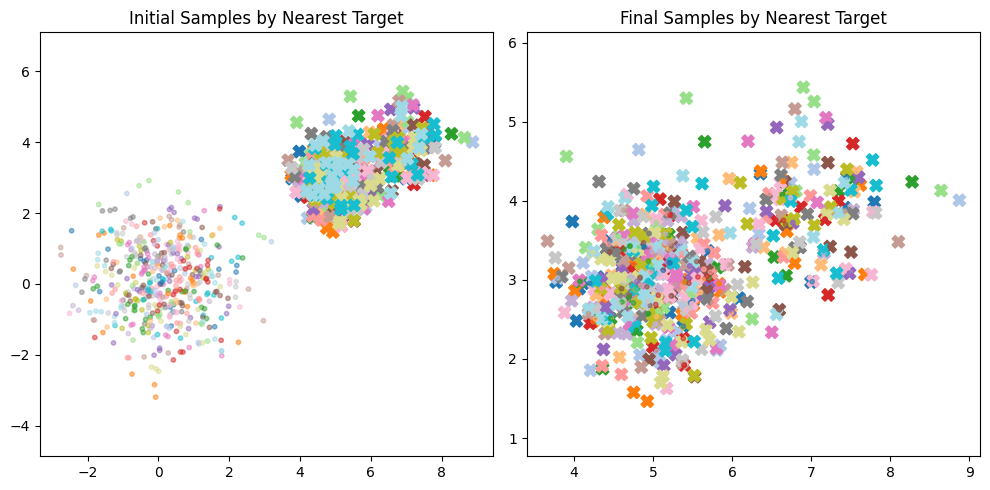

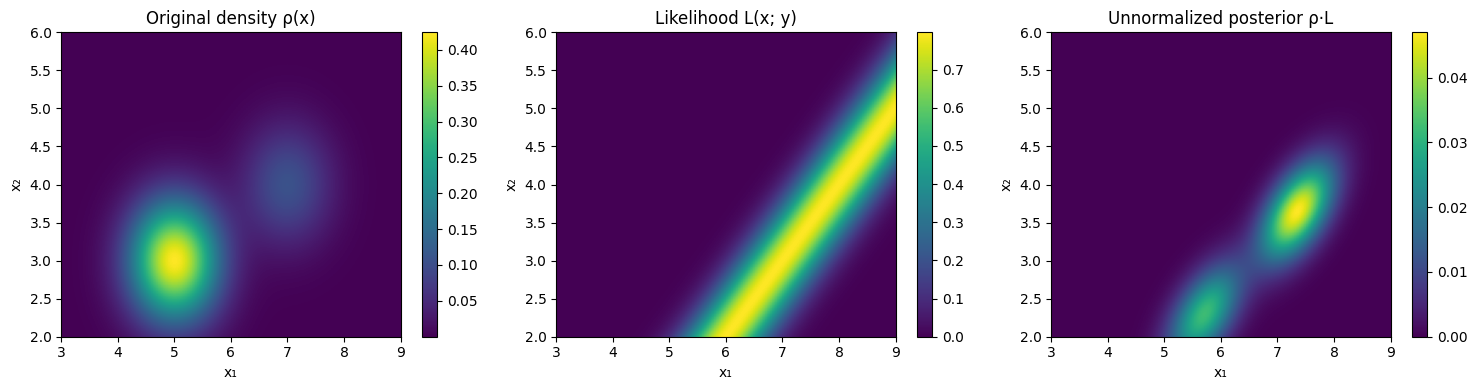

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Main: Parameter Settings and Execution (Torch)
# ----------------------------

# Monte Carlo and generation settings
N_mc      = 500
N_gen     = 500
sigma_min = 1e-3
L_steps   = 100
dt        = 1.0 / L_steps

# target Gaussian mixture parameters (convert to torch tensors)
mus     = torch.tensor([[5.0, 3.0],
                        [7.0, 4.0]], dtype=torch.float32)            # (K=2, 2)
covs    = torch.stack([0.3 * torch.eye(2),
                       0.3 * torch.eye(2)], dim=0)                  # (K=2, 2, 2)
weights = torch.tensor([0.8, 0.2], dtype=torch.float32)               # (K,)

# sample reference targets
X_mc = sample_q(N_mc, mus, covs, weights)                              # (N_mc, 2)

# assign colors for each reference sample (for plotting)
colors = plt.cm.tab20(np.linspace(0, 1, N_mc))

# generate flow-matched samples
Z0, X_gen = generate_flow_samples(N_gen, L_steps, dt, X_mc, sigma_min) # both (N_gen, 2)

# visualize the transformation with torch-based functions
visualize_flow(Z0, X_gen, X_mc, colors)

# ----------------------------
# Heatmap Visualization
# ----------------------------
grid_size = (200, 200)            # grid resolution per axis
lims      = [(3, 9), (2, 6)]      # x and y limits

# observation model parameters (as torch tensors)
H         = torch.tensor([[1.0, -1.0]], dtype=torch.float32)          # (1, 2)
y_obs     = torch.tensor([4], dtype=torch.float32)                  # (1,)
sigma_obs = 0.5                                                        # scalar

# plot original density, likelihood, and posterior heatmaps
visualize_heatmap(grid_size, lims,
                  mus, covs, weights,
                  H, y_obs, sigma_obs)
